In [400]:
# Importo Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display, Math

# Ejercicio 1
 La función de costo marginal de una empresa está dada por $C'(q)=300+20q-12q^2$ y los costos fijos ascienden a $40000.
Determinar la función de costos totales y la de costo medio.
Graficar las funciones de costo medio y marginal en un mismo gráfico. Interpretar.


In [401]:
# Paso 1: Defino las variables simbólicas
q = sp.symbols('q', positive=True)
F = sp.symbols('F')

In [402]:
# Paso 2: Defino función a integrar
CMg = 300 + 20*q - 12*q**2
CMg

-12*q**2 + 20*q + 300

In [403]:
# Paso 3: Calculo integral
C = sp.integrate(CMg, q) + F
C

F - 4*q**3 + 10*q**2 + 300*q

In [404]:
# Valido que CMg sea la derivada de C
CMg == sp.diff(C, q)

True

In [405]:
# Paso 4: Encuentro F sabiendo que C(0) = 40000
condicion = sp.Eq(C.subs(q, 0), 40000)
F_value = sp.solve(condicion, F)[0]
print('F_value:', F_value)

# Substituyo F_value en la función C
C = C.subs(F, F_value)
C

F_value: 40000


-4*q**3 + 10*q**2 + 300*q + 40000

In [406]:
# Paso 5: Hallo la función de Costo Medio
CMed = C / q
CMed = sp.simplify(CMed)
CMed

-4*q**2 + 10*q + 300 + 40000/q

In [407]:
# Paso 6: Grafico CMed y CMg para q entre 1 y 20

# 6.1 Creo dominio
q_vals = np.linspace(1, 20, 100)

In [408]:
# 6.2 Convierto funciones simbólicas a funciones numéricas
CMed_num = sp.lambdify(q, CMed, modules=['numpy']) # type: ignore
CMg_num = sp.lambdify(q, CMg, modules=['numpy']) # type: ignore

In [409]:
# 6.3 Evalúo las funciones en la grilla de valores
CMed_vals = CMed_num(q_vals)
CMg_vals = CMg_num(q_vals)

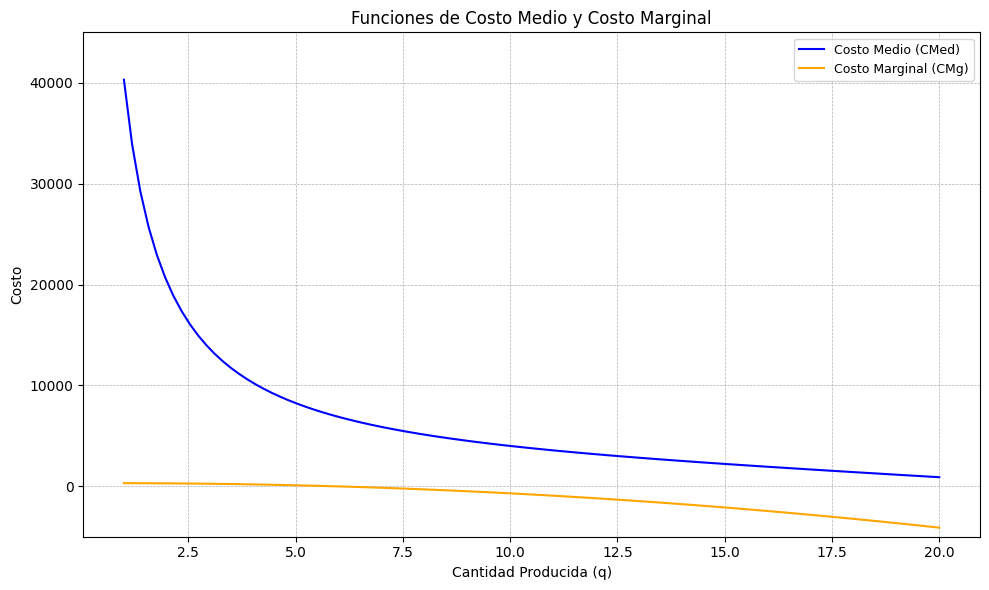

In [410]:
# 6.4 Visualizo las funciones CMed y CMg
fig, axs = plt.subplots(figsize=(10, 6))

# Grafico las funciones
axs.plot(q_vals, CMed_vals, label='Costo Medio (CMed)', color='blue')
axs.plot(q_vals, CMg_vals, label='Costo Marginal (CMg)', color='orange')

# Configuro Gráfico
axs.grid(True, which='both', linestyle='--', linewidth=0.5)
axs.set_title('Funciones de Costo Medio y Costo Marginal')
axs.set_xlabel('Cantidad Producida (q)')
axs.set_ylabel('Costo')
axs.set_ylim(-5000, 45000)
axs.legend(fontsize=9, loc='upper right')

fig.tight_layout()
plt.show()

In [411]:
# Interpretación económica
print("="*70)
print("INTERPRETACIÓN ECONÓMICA DEL GRÁFICO")
print("="*70)
print("\n📊 Relación entre Costo Medio (CMed) y Costo Marginal (CMg):\n")
print("1. Cuando CMg < CMed:")
print("   • El costo marginal está por debajo del costo medio")
print("   • Esto significa que producir una unidad adicional cuesta MENOS")
print("     que el costo promedio actual")
print("   • Por tanto, el CMed está DECRECIENDO\n")

print("2. Punto de cruce (CMg = CMed):")
print("   • Cuando las curvas se intersectan → Punto crítico")
print("   • El costo medio alcanza su MÍNIMO")
print("   • Este es el punto de máxima eficiencia productiva\n")

print("3. Cuando CMg > CMed:")
print("   • El costo marginal supera al costo medio")
print("   • Producir unidades adicionales cuesta MÁS que el promedio actual")
print("   • Por tanto, el CMed está CRECIENDO\n")

print("💡 REGLA ECONÓMICA FUNDAMENTAL:")
print("   El Costo Marginal SIEMPRE corta al Costo Medio en su punto MÍNIMO")
print("\n📈 IMPLICACIONES GERENCIALES:")
print("   • Antes del punto de cruce: aumentar producción reduce costos promedio")
print("   • Después del punto de cruce: aumentar producción incrementa costos promedio")
print("   • La decisión de producción óptima depende también del precio de mercado")
print("="*70)

INTERPRETACIÓN ECONÓMICA DEL GRÁFICO

📊 Relación entre Costo Medio (CMed) y Costo Marginal (CMg):

1. Cuando CMg < CMed:
   • El costo marginal está por debajo del costo medio
   • Esto significa que producir una unidad adicional cuesta MENOS
     que el costo promedio actual
   • Por tanto, el CMed está DECRECIENDO

2. Punto de cruce (CMg = CMed):
   • Cuando las curvas se intersectan → Punto crítico
   • El costo medio alcanza su MÍNIMO
   • Este es el punto de máxima eficiencia productiva

3. Cuando CMg > CMed:
   • El costo marginal supera al costo medio
   • Producir unidades adicionales cuesta MÁS que el promedio actual
   • Por tanto, el CMed está CRECIENDO

💡 REGLA ECONÓMICA FUNDAMENTAL:
   El Costo Marginal SIEMPRE corta al Costo Medio en su punto MÍNIMO

📈 IMPLICACIONES GERENCIALES:
   • Antes del punto de cruce: aumentar producción reduce costos promedio
   • Después del punto de cruce: aumentar producción incrementa costos promedio
   • La decisión de producción óptima depe

# Ejercicio 2

**Problema:**

Supongamos que la función de ingreso marginal de una empresa está dada por:

$$ IMg(q) = 50 - 0.5 \cdot q $$

donde $q$ es la cantidad producida.

Además, sabemos que el costo marginal de la empresa es:

$$ CMg(q) = 10 + 0.3 \cdot q $$

y que el costo fijo es de $100.

**Resolver los siguientes puntos:**

1.  **Recuperar la función de ingreso total (I(q))**: Utiliza la integral indefinida para obtener la función de ingreso total a partir del ingreso marginal. Recuerda que el ingreso total es cero cuando la cantidad producida es cero ($I(0) = 0$).
2.  **Recuperar la función de costo total (C(q))**: Utiliza la integral indefinida para obtener la función de costo total a partir del costo marginal. Utiliza la información del costo fijo para determinar la constante de integración.
3.  **Calcular la función de beneficio total (B(q))**: Resta la función de costo total de la función de ingreso total para obtener la función de beneficio total.
4.  **Encontrar la cantidad óptima (q*)**: Determina la cantidad de producción que maximiza el beneficio igualando el ingreso marginal al costo marginal ($IMg(q) = CMg(q)$) y resolviendo para $q$.
5.  **Calcular el beneficio máximo (B(q*))**: Sustituye la cantidad óptima ($q^{*}$) en la función de beneficio total para encontrar el beneficio máximo.
6.  **Visualizar las funciones**: Grafica las funciones de ingreso total, costo total y beneficio total en el mismo gráfico para visualizar el punto de beneficio máximo.

In [412]:
# Paso 1: Defino las variables simbólicas
q = sp.symbols('q', positive=True)

In [413]:
# Paso 2: Defino función a integrar
IMg = 50.0 - 0.5 * q
IMg

50.0 - 0.5*q

In [414]:
# Paso 3: Integro para obtener la función de Ingreso Total
K = sp.symbols('K')
I = sp.integrate(IMg, q) + K
I

K - 0.25*q**2 + 50.0*q

In [415]:
# Paso 4: Determino la constante K usando la condición I(0) = 0
condicion_I = sp.Eq(I.subs(q, 0), 0)
K_value = sp.solve(condicion_I, K)[0]
print('K_value:', K_value)

# Substituyo K_value en la función I
I = I.subs(K, K_value)
I

K_value: 0


-0.25*q**2 + 50.0*q

2.  **Recuperar la función de costo total (C(q))**: Utiliza la integral indefinida para obtener la función de costo total a partir del costo marginal. Utiliza la información del costo fijo para determinar la constante de integración.
$$ CMg(q) = 10 + 0.3 \cdot q $$

y que el costo fijo es de $100.

In [ ]:
# Verifico que IMg sea la derivada de I
IMg == sp.diff(I, q)

True

In [417]:
# Paso 1: Defino las variables simbólicas
# q ya está definida en el paso anterior

F = sp.symbols('F')

In [418]:
# Paso 2: Defino función marginal
CMg = 10.0 + 0.3*q
CMg

0.3*q + 10.0

In [419]:
# Paso 3: Integro para obtener la función de Costo Total
C = sp.integrate(CMg, q) + F
C

F + 0.15*q**2 + 10.0*q

In [420]:
# Verifico que CMg sea la derivada de C
CMg == sp.diff(C,q)

True

In [421]:
# Paso 4: Determino la constante de integración F
# 4.1 Encuentro F sabiendo que C(0) = 100
condicion = sp.Eq(C.subs(q,0), 100)
F_value = sp.solve(condicion, F)[0]

# 4.2 Substituyo F_value en la función C
C = C.subs(F, F_value)
C

0.15*q**2 + 10.0*q + 100

3.  **Calcular la función de beneficio total (B(q))**: Resta la función de costo total de la función de ingreso total para obtener la función de beneficio total.

In [422]:
B = I - C
B

-0.4*q**2 + 40.0*q - 100

4.  **Encontrar la cantidad óptima (q*)**: Determina la cantidad de producción que maximiza el beneficio igualando el ingreso marginal al costo marginal ($IMg(q) = CMg(q)$) y resolviendo para $q$.

In [423]:
q_opt = sp.solve(sp.Eq(IMg, CMg), q)[0]
q_opt

50.0000000000000

5.  **Calcular el beneficio máximo (B(q*))**: Sustituye la cantidad óptima ($q^{*}$) en la función de beneficio total para encontrar el beneficio máximo.

In [424]:
B_opt = B.subs(q, q_opt)
B_opt

900.000000000000

6.  **Visualizar las funciones**: Grafica las funciones de ingreso total, costo total y beneficio total en el mismo gráfico para visualizar el punto de beneficio máximo.

In [425]:
# 6.1 Creo dominio
q_vals = np.linspace(0, 100, 200)

In [426]:
# 6.2 Convierto funciones simbólicas a funciones numéricas
I_num = sp.lambdify(q, I, modules=['numpy'])
C_num = sp.lambdify(q, C, modules=['numpy'])
B_num = sp.lambdify(q, B, modules=['numpy'])

In [427]:
# 6.3 Evalúo las funciones en la grilla de valores
I_vals = I_num(q_vals)
C_vals = C_num(q_vals)
B_vals = B_num(q_vals)

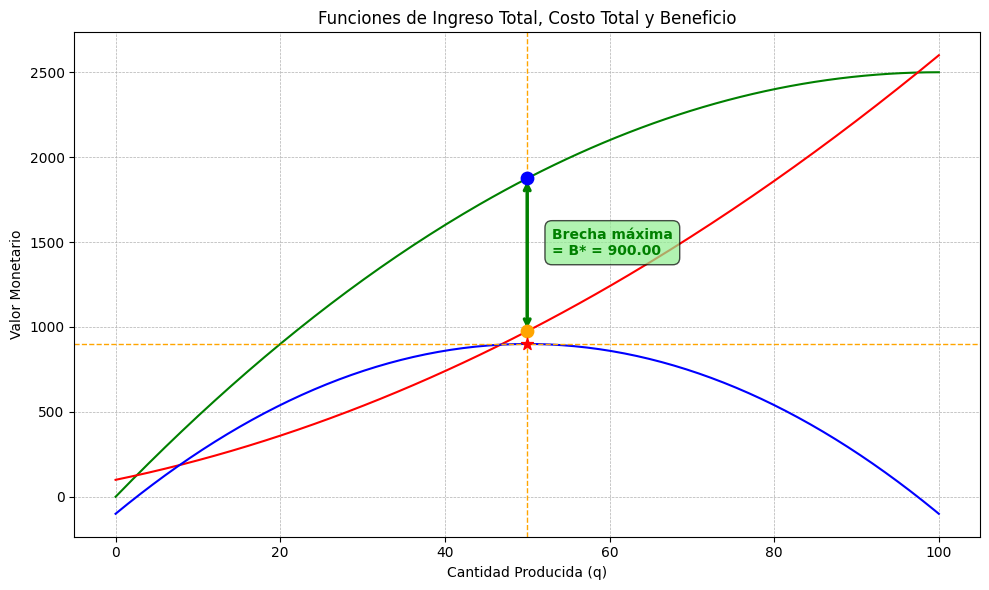

In [428]:
# 6.4 Creo el gráfico
fig, axs = plt.subplots(figsize=(10, 6))

# Grafico las funciones
axs.plot(q_vals, I_vals, label='Ingreso Total (I)', color='green')
axs.plot(q_vals, C_vals, label='Costo Total (C)', color='red')
axs.plot(q_vals, B_vals, label='Beneficio (B)', color='blue')

I_opt = float(I_num(q_opt))
C_opt = float(C_num(q_opt))

# Marco el punto óptimo
axs.scatter(q_opt, B_opt, color='red', s=80, label=f'Óptimo: q*={q_opt:.2f}, B*={B_opt:.2f}', marker='*', zorder=5)
axs.scatter(q_opt, I_opt, color='blue', s=80, zorder=4, marker='o')
axs.scatter(q_opt, C_opt, color='orange', s=80, zorder=4, marker='o')

# Líneas de referencias
axs.axvline(x=q_opt, color='orange', linestyle='--', linewidth=1)
axs.axhline(y=B_opt, color='orange', linestyle='--', linewidth=1)

# Flecha bidireccional mostrando la distancia máxima (beneficio)
axs.annotate('', 
            xy=(q_opt, I_opt), 
            xytext=(q_opt, C_opt),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2.5))

# Etiqueta explicativa de la brecha
axs.text(q_opt + 3, (I_opt + C_opt) / 2, 
        f'Brecha máxima\n= B* = {B_opt:.2f}', 
        fontsize=10, color='green', fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.7))

# Configuro Gráfico
axs.grid(True, which='both', linestyle='--', linewidth=0.5)
axs.set_title('Funciones de Ingreso Total, Costo Total y Beneficio')
axs.set_xlabel('Cantidad Producida (q)')
axs.set_ylabel('Valor Monetario')

plt.tight_layout()
plt.show()


In [429]:
# Interpretación económica
print("="*70)
print("INTERPRETACIÓN ECONÓMICA DEL EJERCICIO 2")
print("="*70)
print(f"\n📊 RESULTADOS OBTENIDOS:\n")
print(f"   • Cantidad óptima de producción: q* = {q_opt:.2f} unidades")
print(f"   • Beneficio máximo: B* = ${B_opt:.2f}")
print(f"   • Ingreso en el óptimo: I(q*) = ${I_opt:.2f}")
print(f"   • Costo en el óptimo: C(q*) = ${C_opt:.2f}")

print("\n💡 INTERPRETACIÓN DEL RESULTADO:\n")
print("1. Condición de optimización:")
print("   • El beneficio se maximiza cuando IMg = CMg")
print(f"   • En q* = {q_opt:.2f}, ambas funciones marginales son iguales")
print("   • Esto significa que el ingreso adicional de la última unidad")
print("     es exactamente igual al costo adicional de producirla\n")

print("2. Significado de la brecha I-C:")
print("   • La distancia vertical entre las curvas I(q) y C(q)")
print("     representa el beneficio B(q)")
print(f"   • Esta brecha es MÁXIMA en q* = {q_opt:.2f}")
print(f"   • El beneficio máximo alcanzado es B* = ${B_opt:.2f}\n")

print("3. Análisis de la visualización:")
print("   • Curva verde (I): Ingreso total - función cóncava decreciente")
print("   • Curva roja (C): Costo total - función convexa creciente")
print("   • Curva azul (B): Beneficio - parábola con máximo en q*")
print("   • La flecha verde muestra la brecha I-C en el punto óptimo\n")

print("📈 IMPLICACIONES GERENCIALES:\n")
print(f"   • Si la empresa produce MENOS de {q_opt:.2f} unidades:")
print("     → Está dejando de capturar beneficios potenciales")
print("     → IMg > CMg, conviene aumentar producción")
print(f"\n   • Si la empresa produce MÁS de {q_opt:.2f} unidades:")
print("     → Está reduciendo su beneficio total")
print("     → IMg < CMg, conviene reducir producción")
print(f"\n   • La producción óptima es exactamente q* = {q_opt:.2f} unidades")
print("="*70)

INTERPRETACIÓN ECONÓMICA DEL EJERCICIO 2

📊 RESULTADOS OBTENIDOS:

   • Cantidad óptima de producción: q* = 50.00 unidades
   • Beneficio máximo: B* = $900.00
   • Ingreso en el óptimo: I(q*) = $1875.00
   • Costo en el óptimo: C(q*) = $975.00

💡 INTERPRETACIÓN DEL RESULTADO:

1. Condición de optimización:
   • El beneficio se maximiza cuando IMg = CMg
   • En q* = 50.00, ambas funciones marginales son iguales
   • Esto significa que el ingreso adicional de la última unidad
     es exactamente igual al costo adicional de producirla

2. Significado de la brecha I-C:
   • La distancia vertical entre las curvas I(q) y C(q)
     representa el beneficio B(q)
   • Esta brecha es MÁXIMA en q* = 50.00
   • El beneficio máximo alcanzado es B* = $900.00

3. Análisis de la visualización:
   • Curva verde (I): Ingreso total - función cóncava decreciente
   • Curva roja (C): Costo total - función convexa creciente
   • Curva azul (B): Beneficio - parábola con máximo en q*
   • La flecha verde muest